# **UCI Online Retail Customer Segmentation Project**
Rheymar Devera

## **Project Overview**
This project aims to identify different customer groups based on their purchasing behavior to help this company create marketing strategies to improve customer retention and increase revenue. This project will also look into the general analysis of the stores business, acquiring insights such as sales trends, customer trends, popular products, and performance over time. 

The dataset I will be using is a transactional data set containing transactions occurring between  2009-2011, for a UK-based online retail store. The link for this data set can be accessed [here](https://archive.ics.uci.edu/dataset/352/online+retail). 

The data set consists of 8 variables:
- **InvoiceNo**: A 6-digit integral number assigned to each transaction. Code starting with 'c' indicates a cancellation. 
- **StockCode**: A 5-digit integral number uniquely assigned to each distinct product
- **Description**: The product name
- **Quantity**: The amount of each product per transaction
- **InvoiceDate**: The date and time each transaction was generated
- **UnitPrice**: Product Price per unit
- **CustomerID**: Unique 5-digit IDs uniquely assigned to each customer
- **Country**: The name of the country where the customer purchased an item

This project will go through these steps:
1. Data Cleaning and Preparation
2. Sales Analysis
3. Cohort Analysis
4. SFM Analysis
5. Recommendations

## **Data Cleaning and Preparation**
Before cleaning the dataset, we need to set up the environment and load in the excel file for analysis.

In [1]:
# load libraries
import pandas as pd
import numpy as np
import datetime as dt
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset as a dataframe
df = pd.read_excel("online_retail_II.xlsx", sheet_name=None)

In [2]:
# combine sheets
df = pd.concat(df.values(), ignore_index=True)

Now that the environment is set up, we can now start exploring the dataset and check for any values that need cleaning.

In [3]:
# check if the dataset has loaded correctly
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.count()

Invoice        1067371
StockCode      1067371
Description    1062989
Quantity       1067371
InvoiceDate    1067371
Price          1067371
Customer ID     824364
Country        1067371
dtype: int64

In [5]:
# print dataframe information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [6]:
# check null values
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [7]:
# dropping NA values for customer ID
retaildf_clean = df.dropna(subset=['Customer ID'])
retaildf_clean.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [8]:
# change customer ID to int
retaildf_clean['Customer ID'] = retaildf_clean['Customer ID'].astype(np.int64)

/var/folders/bp/qs71ygfd61n4f2w3xl11qdqr0000gn/T/ipykernel_75331/3345241687.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  retaildf_clean['Customer ID'] = retaildf_clean['Customer ID'].astype(np.int64)


In [9]:
# check for duplicates
retaildf_clean.duplicated().sum()

np.int64(26479)

In [10]:
# drop duplicates
retaildf_clean = retaildf_clean.drop_duplicates()
retaildf_clean.duplicated().sum()

np.int64(0)

In [11]:
# check dataset quantities
retaildf_clean.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,797885.000000,797885,797885.000000,797885.000000
mean,12.602980,2011-01-02 13:17:34.141160704,3.702732,15313.062777
min,-80995.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,2.000000,2010-07-02 09:47:00,1.250000,13964.000000
50%,5.000000,2010-12-02 12:33:00,1.950000,15228.000000
75%,12.000000,2011-07-31 15:50:00,3.750000,16788.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,191.670371,NaN,71.392549,1696.466663


In [12]:
# remove negative and zero values in quantity and price
retaildf_clean = retaildf_clean[(retaildf_clean["Quantity"] > 0) & (retaildf_clean["Price"] > 0)]
retaildf_clean.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,779425.000000,779425,779425.000000,779425.000000
mean,13.489370,2011-01-03 01:44:42.593475584,3.218488,15320.360461
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000
25%,2.000000,2010-07-02 14:39:00,1.250000,13971.000000
50%,6.000000,2010-12-02 14:09:00,1.950000,15247.000000
75%,12.000000,2011-08-01 13:44:00,3.750000,16794.000000
max,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000
std,145.855814,NaN,29.676140,1695.692775


### First Observations
This dataset had various problems that needed to be addressed before being able to be used for analysis. This included:
- **Null values for 'Customer ID' and 'Description'**: This was resolved by dropping NA customer IDs since they wouldn't be able to be used for analysis.
- **Duplicate values in the data**: Duplicate rows in the dataset represented identical records of the same item purchase repeated more than once. We want to remove this redundancy to prevent inflated totals and incorrect segmentation, so these duplicates were removed.
- **Negative and Zero values for 'Quantity' and 'Price'**: These negative values represent any returns a customer makes. These negative values need to be removed since I am focusing on customer purchase behavior. 

Next, I want to ensure that 'InvoiceDate' is properly extracted for time series analysis. I also want to create a TotalPrice column to compute total revenue per item invoice.

In [13]:
# extract from invoice date to time components
retaildf_clean["YearMonth"] = retaildf_clean["InvoiceDate"].dt.to_period("M")

In [14]:
# create TotalPrice column
retaildf_clean["TotalPrice"] = retaildf_clean["Quantity"] * retaildf_clean["Price"]

In [15]:
# check work
retaildf_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,YearMonth,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,2009-12,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009-12,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009-12,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,2009-12,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,2009-12,30.0


In [16]:
# save df as csv
retaildf_clean.to_csv('Cleaned_Retail.csv')

## **Sales Analysis**
Now that I have cleaned and pre-processed the dataset, we can now start exploring the data to gain insights on sales and customer behavior. 

### Which products had the most and least sales?

In [17]:
# total revenue per product
product_sales = (
    retaildf_clean.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

product_sales.head(10)

,Description,TotalPrice
0,REGENCY CAKESTAND 3 TIER,277656.25
1,WHITE HANGING HEART T-LIGHT HOLDER,247048.01
2,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3,Manual,151777.67
4,JUMBO BAG RED RETROSPOT,134307.44
5,POSTAGE,124648.04
6,ASSORTED COLOUR BIRD ORNAMENT,124351.86
7,PARTY BUNTING,103283.38
8,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
9,PAPER CHAIN KIT 50'S CHRISTMAS,76598.18


In [18]:
# least revenue products
product_sales.tail(10)

,Description,TotalPrice
5273,FAIRY DESIGN MUGS,1.250
5274,SET 36 COLOURING PENCILS DOILEY,1.250
5275,FOLKART HEART CHRISTMAS DECORATIONS,1.250
5276,CAT WITH SUNGLASSES BLANK CARD,0.950
5277,OWLS CHARLOTTE BAG,0.850
5278,CAT W SUNGLASSES BLANK CARD,0.760
5279,SET 12 COLOURING PENCILS DOILEY,0.650
5280,PINK HEART CHRISTMAS DECORATION,0.380
5281,HAPPY BIRTHDAY GINGER CAT CARD,0.380
5282,PADS TO MATCH ALL CUSHIONS,0.017


In [19]:
# total quantity sold per product
product_quantity_sold = (
    retaildf_clean.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
product_quantity_sold.head(10)

,Description,Quantity
0,WORLD WAR 2 GLIDERS ASSTD DESIGNS,105185
1,WHITE HANGING HEART T-LIGHT HOLDER,91757
2,"PAPER CRAFT , LITTLE BIRDIE",80995
3,ASSORTED COLOUR BIRD ORNAMENT,78234
4,MEDIUM CERAMIC TOP STORAGE JAR,77916
5,JUMBO BAG RED RETROSPOT,74224
6,BROCADE RING PURSE,70082
7,PACK OF 60 PINK PAISLEY CAKE CASES,54592
8,60 TEATIME FAIRY CAKE CASES,52828
9,PACK OF 72 RETRO SPOT CAKE CASES,45129


In [20]:
# products with least amount of quantity sold
product_quantity_sold.tail(10)

,Description,Quantity
5273,DOOR MAT BLUE FLOCK,1
5274,HEXAGONAL CRYSTAL PERFUME BOTTLE,1
5275,"BLACK RND BULLET""KEEP CLEAN"" BIN",1
5276,SET 10 CARDS HANGING BAUBLES 17080,1
5277,WHITE SCANDINAVIAN HEART CHRISTMAS,1
5278,PINK STRIPES SHOULDER BAG,1
5279,SILVER AND BLACK ORBIT NECKLACE,1
5280,BLACK DIAMOND CLUSTER EARRINGS,1
5281,SET/2 SPOTTY + ROSE TEA TOWELS,1
5282,SET 12 COLOURING PENCILS DOILEY,1


Here we can see the total sales of products, based on the revenue they produced and quantity sold. Both lists show the retailer that those products perform the best, allowing them to learn from them to apply their success to other items. This can be due to how they advertise, sell, or discount these products. 

We can also see here that price may not correlate with total quantity sold, as different items may just have higher prices creating higher revenues, without outselling another item. For example, 'Regency Cakestand 3 tier' created a revenue of £277k, but is not within the top 10 for total quantity sold.

On the other hand, we can also see products with the least amount of revenue produced and items sold. This can help the retailer decide whether to promote these products more or remove them to reduce unnecessary costs. 

### Which customers generate the most revenue?

In [21]:
# groups customer IDs with their total price purchased
customer_revenue = (
    retaildf_clean.groupby("Customer ID")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# bar graph for customer revenue
top_customers = customer_revenue.head(10)
fig = px.bar(
    top_customers,
    x=top_customers['Customer ID'].astype(str),
    y="TotalPrice",
    color="TotalPrice",
    color_continuous_scale="bluered",
    title="Top 10 Customers by Total Revenue",
    text_auto=".2s"
)

fig.update_coloraxes(showscale=False)
fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title = "Customer ID",
    yaxis_title = "Total Amount (£)"
)

fig.show()



### Which countries generate the most sales?

In [22]:
# sorts countries by total amount spent by users in them
country_sales = (
    retaildf_clean.groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# bar graph for sales per country
fig = px.bar(
    country_sales.head(10),
    x="Country",
    y="TotalPrice",
    color="Country",
    title="Top 10 Countries by Total Sales",
    labels={"Country": "Country", "TotalPrice": "Total Revenue (£)"},
    text_auto=".2s",
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

fig.show()


### What are the monthly sales trends?

In [23]:
# group by monthly sales
monthly_sales = retaildf_clean.groupby(retaildf_clean["InvoiceDate"].dt.to_period("M"))["TotalPrice"].sum().reset_index()
monthly_sales["InvoiceDate"] = monthly_sales["InvoiceDate"].dt.to_timestamp()
monthly_sales.columns = ["Date", "Revenue"]

# time series chart
fig = px.line(
    monthly_sales,
    x="Date",
    y="Revenue",
    title="Monthly Sales Over Time",
    markers=True,
    labels={"Date": "Month", "Revenue": "Total Sales (£)"},
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
)
fig.show()

By looking at which customers produce the most revenue as well as which country produces the most revenue, the retailor can adjust its focus on those customers and markets. For example, introducing higher incentives (cash back, rewards program, discounts, etc.) to these top customers to keep shopping with the retailor, as well as encouraging new or repeating customers to stay loyal to them. 

Country insight show the markets the retailors present in. For example, they can continue to market themselves and advertise more in the UK due to them being the most popular there, but they could also focus on other countries like EIRE or the Netherlands to gain sales there. 

There also seems to be a clear pattern in the time series chart, which shows monthly sales over two years. We can see that both years they peak in November, with a sharp fall once December hits. That shows a clear indicator of seasonal demand, where the retailor sees a large revenue surge starting the holiday season. They can plan marketing campaigns and inventory around this, maximizing profit within those windows. They can then expect a dip post-holiday, and adjust accordingly.

## **Cohort Analysis**
Now that I have a general idea of the retailers sales, I want to look into customer behaviour. I will be doing this by performing a cohort analysis, which will allow me to find insights about customer experiences and how to improve them. 

I will do a time cohort, where I can see the customers who purchased a product from this retailer during a particular time frame. I want to look into customers behaviours over time, seeing if theres any trends over retention. I also want to see their average amount of products bought over time, offering insight into more popular months or seasons.

In [24]:
# extract invoice month
retaildf_clean["InvoiceMonth"] = retaildf_clean["InvoiceDate"].dt.to_period("M")

# find each customers first purchase month
retaildf_clean["CohortMonth"] = retaildf_clean.groupby("Customer ID")["InvoiceDate"].transform("min").dt.to_period("M")

# calculate cohort index
def cohort_period(df):
    return (df["InvoiceMonth"].dt.year - df["CohortMonth"].dt.year) * 12 + (df["InvoiceMonth"].dt.month - df["CohortMonth"].dt.month) + 1

retaildf_clean["CohortIndex"] = cohort_period(retaildf_clean)

# check table
retaildf_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,YearMonth,TotalPrice,InvoiceMonth,CohortMonth,CohortIndex
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,2009-12,83.40,2009-12,2009-12,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009-12,81.00,2009-12,2009-12,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009-12,81.00,2009-12,2009-12,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,2009-12,100.80,2009-12,2009-12,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,2009-12,30.00,2009-12,2009-12,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,2011-12,12.60,2011-12,2011-08,5
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,2011-12,16.60,2011-12,2011-08,5
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,2011-12,16.60,2011-12,2011-08,5
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France,2011-12,14.85,2011-12,2011-08,5


In [25]:
# build cohort table
cohort_data = retaildf_clean.groupby(["CohortMonth", "CohortIndex"])["Customer ID"].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index="CohortMonth", columns="CohortIndex", values="Customer ID")

# calc retention percentages
cohort_size = cohort_pivot.iloc[:,0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3)

retention

CohortIndex,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,1.0,0.353,0.334,0.425,0.380,0.359,0.377,0.342,0.336,0.362,...,0.303,0.263,0.303,0.283,0.260,0.255,0.315,0.305,0.407,0.197
2010-01,1.0,0.206,0.311,0.305,0.264,0.300,0.258,0.230,0.279,0.319,...,0.151,0.235,0.198,0.185,0.196,0.243,0.193,0.245,0.057,NaN
2010-02,1.0,0.238,0.225,0.291,0.246,0.201,0.193,0.286,0.254,0.275,...,0.201,0.160,0.163,0.144,0.230,0.230,0.163,0.059,NaN,NaN
2010-03,1.0,0.190,0.230,0.242,0.233,0.203,0.246,0.302,0.275,0.108,...,0.169,0.174,0.156,0.176,0.201,0.212,0.079,NaN,NaN,NaN
2010-04,1.0,0.194,0.194,0.163,0.184,0.224,0.276,0.262,0.105,0.109,...,0.156,0.139,0.150,0.180,0.224,0.058,NaN,NaN,NaN,NaN
2010-05,1.0,0.157,0.169,0.173,0.177,0.256,0.213,0.126,0.059,0.083,...,0.126,0.138,0.165,0.154,0.047,NaN,NaN,NaN,NaN,NaN
2010-06,1.0,0.174,0.189,0.204,0.230,0.285,0.126,0.089,0.081,0.119,...,0.122,0.133,0.204,0.052,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,1.0,0.156,0.183,0.296,0.290,0.140,0.113,0.145,0.145,0.113,...,0.172,0.237,0.081,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,1.0,0.204,0.296,0.321,0.173,0.117,0.099,0.123,0.136,0.130,...,0.198,0.068,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Customer Retention Over Time

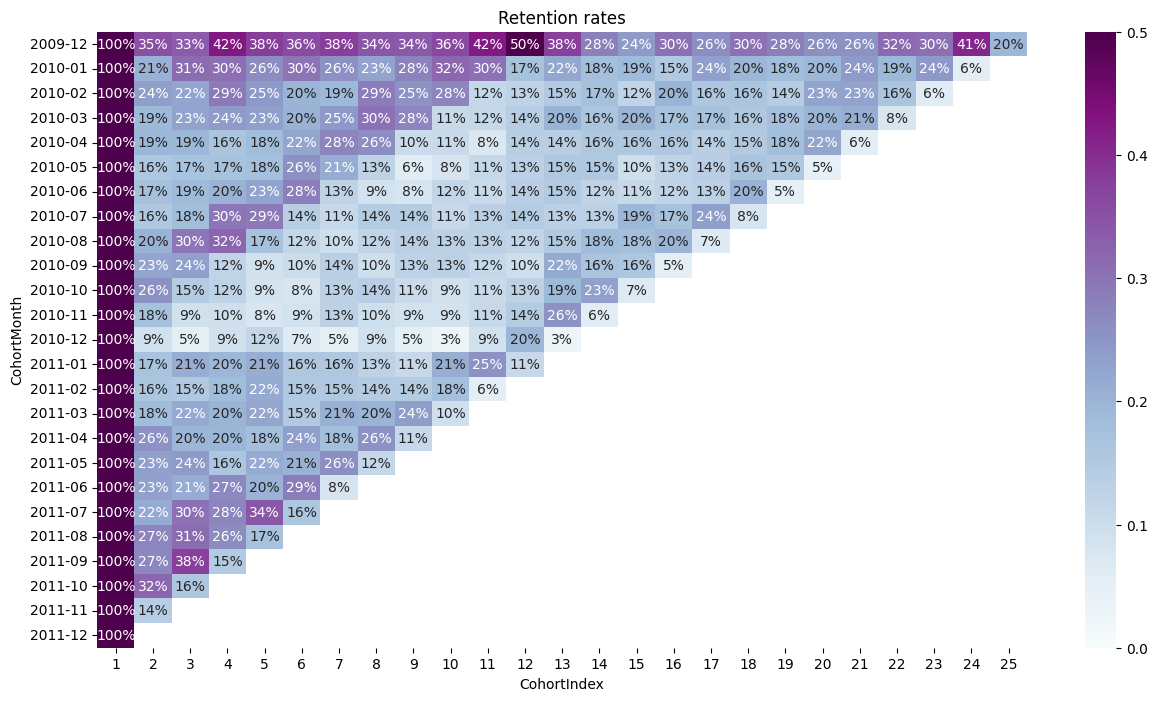

In [26]:
# heatmap of retention over time
plt.figure(figsize=(15, 8))
plt.title('Retention rates')
sns.heatmap(data=retention,annot = True,fmt = '.0%',vmin = 0.0,vmax = 0.5,cmap="BuPu")
plt.show()

This heatmap represents retention over time, showing how well the retailer retains customers after their first purchase. We can see that there is a sharp drop early (100% -> ~20%), where most customers buy once from the store and leave. However, there are still a consistent amount of loyal customers even after 6 months (10-20%). We can also observe that some months show stronger early retention, representing seasonal strength or due to the retailors marketing tactics (discounts, rewards, etc). 

We can use this heatmap to create data-driven decisions, including actions such as identifying and rewarding loyal and returning customers. We can also research more successful months to repeat successful tactics, and keep monitoring sales to maximize revenue and retention.

### Average Quantity of Items Purchased Per Customer over time

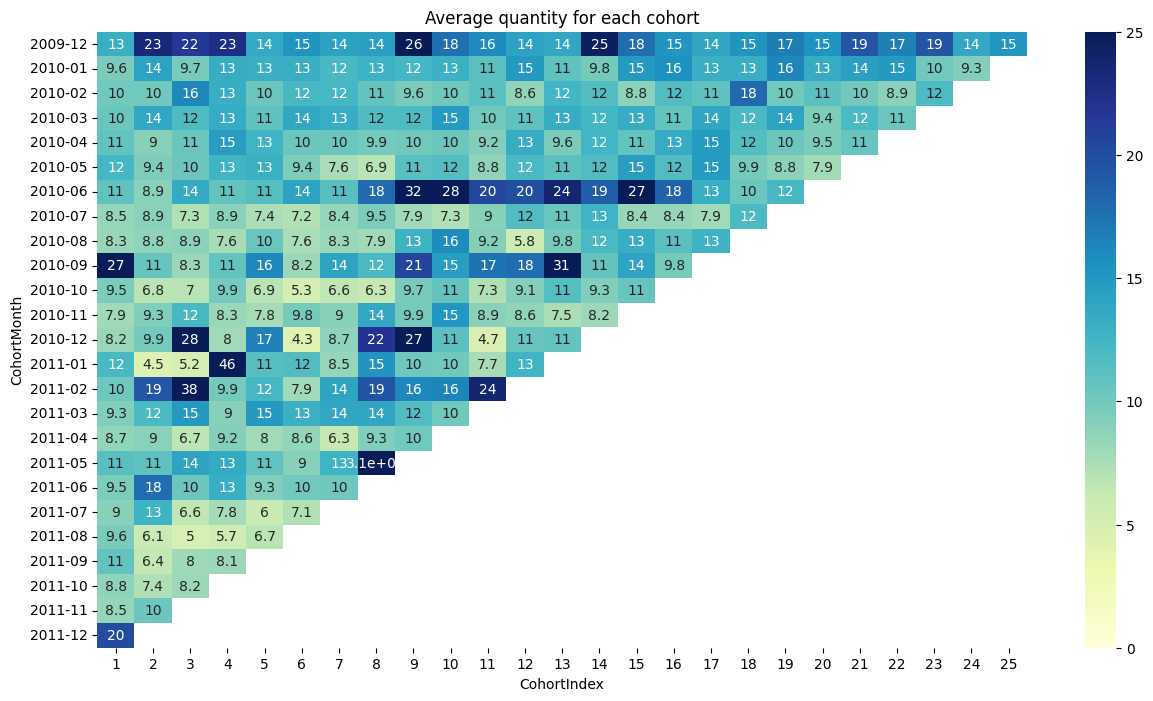

In [27]:
# find avg quantity
cohort_data = retaildf_clean.groupby(["CohortMonth", "CohortIndex"])["Quantity"].mean().reset_index()
cohort_pivot = cohort_data.pivot(index="CohortMonth", columns="CohortIndex", values="Quantity")

# build the heatmap
plt.figure(figsize=(15, 8))
plt.title('Average quantity for each cohort')
sns.heatmap(data=cohort_pivot,annot = True,vmin = 0.0,vmax =25,cmap="YlGnBu")
plt.show()

This heatmap shows insight into buying behavior trends over time. More specifically, the average quantity of items purchased per customer over time grouped by their first purchase month. Overall, customers tend to buy a consistent average amount of items per month (8-15), with higher average quantities starting around mid 2010 and early 2011. This suggests stronger buying periods due to seasonal effects or deals/ discounts, with occasional spikes in averages to stock up for the holidays. 

## **RFM Analysis**

Now I will perform an RFM analysis, which refers to recency, frequency and monetary value. Recency refers to the last order of a customer, meaning the number of days since a customer last made a purchase. Frequency is the number of purchases in a given period, offering insight for how often a customer has bought from the company. Monetary refers to the total amount of money a customer spent in that given period. I'll be grouping them based on their RFM score, sectioned into three groups: High Value, Mid-Value, and Low Value.

In [28]:
# set snapshot date for rfm scoring
snapshot_date = retaildf_clean["InvoiceDate"].max() + dt.timedelta(days=1)
print("Snapshot date:", snapshot_date)

Snapshot date: 2011-12-10 12:50:00


In [29]:
# create rfm table
rfm = retaildf_clean.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",                                     
    "TotalPrice": "sum"                                       
}).reset_index()

rfm.rename(columns={
    "InvoiceDate": "Recency",
    "Invoice": "Frequency",
    "TotalPrice": "Monetary"
}, inplace=True)

rfm.head(10)

,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40
5,12351,375,1,300.93
6,12352,36,10,2849.84
7,12353,204,2,406.76
8,12354,232,1,1079.40
9,12355,214,2,947.61


In [30]:
# assign r, f, m scores
rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1]).astype(int)
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5]).astype(int)

# give rfm segment and overall score
rfm["RFM_Segment"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)
rfm["RFM_Score"] = rfm[["R_Score", "F_Score", "M_Score"]].sum(axis=1)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score
0,12346,326,12,77556.46,2,5,5,255,12
1,12347,2,8,4921.53,5,4,5,545,14
2,12348,75,5,2019.40,3,4,4,344,11
3,12349,19,4,4428.69,5,3,5,535,13
4,12350,310,1,334.40,2,1,2,212,5


In [31]:
# segment customers into different groups
def segment_customer(score):
    if score >= 10:
        return "High Value"
    elif score > 5 and score < 10:
        return "Mid-Value"
    else:
        return "Low-Value"

rfm["Segment"] = rfm["RFM_Score"].apply(segment_customer)
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score,Segment
0,12346,326,12,77556.46,2,5,5,255,12,High Value
1,12347,2,8,4921.53,5,4,5,545,14,High Value
2,12348,75,5,2019.40,3,4,4,344,11,High Value
3,12349,19,4,4428.69,5,3,5,535,13,High Value
4,12350,310,1,334.40,2,1,2,212,5,Low-Value


In [32]:
segment_summary = (
    rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]]
    .mean()
    .round(2)
    .sort_values("Monetary", ascending=False)
)
segment_summary

,Recency,Frequency,Monetary
Segment,,,
High Value,61.60,11.62,5883.93
Mid-Value,219.00,2.43,755.46
Low-Value,458.73,1.14,245.91


In [33]:
# Get customer counts per segment and rename columns
segment_counts = rfm["Segment"].value_counts().reset_index()
segment_counts.columns = ["Segment", "Count"]

# Create bar chart
fig = px.bar(
    segment_counts,
    x="Segment",
    y="Count",
    text_auto=True,
    color="Segment",
    color_discrete_sequence=px.colors.qualitative.Vivid,
    title="Customer Count by Segment",
    labels={"Segment": "Segment", "Count": "Number of Customers"}
)

fig.update_layout(template="plotly_white", title_x=0.5)
fig.show()

In [34]:
segment_revenue = rfm.groupby("Segment")["Monetary"].sum().reset_index()
fig = px.pie(
    segment_revenue,
    names="Segment",
    values="Monetary",
    title="Revenue Contribution by Segment",
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_traces(textposition="inside", textinfo="percent+label")
fig.show()


### **SFM Insights**
From this SFM segmentation, we can see how different customers contribute to this business. This analysis shows clear differences in customer behavior and value across these three segments, with High-Value customers generating the most revenue (89.8%) and an average frequency of 11.6 and recency of 61 days. 

Mid-value customers purchase less frequently (2.4) and contribute 8.34% of the revenue, while low value customers have the least engagement, with long gaps between purchases (410 day average) and only contributing to 3.06% of the total revenue. 

## **Recommendations**

From this analysis, we learn a lot about this UK retailers business and sales. Here are some reccomendations I'm able to make based off of the insights gained from this project:
- **Country Marketing**: We saw that the UK has the leading amount of purchases (~£14M), with other countries in the dataset not even reaching a revenue of £1M. This is valuable for the marketing team if they ever want to expand influence in other countries, especially countries like France and Denmark with low purchase value (regionl expansion or diversification).
- **Seasonal Trends**: From the time series graph, we can see that sales peak around the holiday season then drop sharply once December/January hits. The retailer can focus on increasing inventory, hiring staff, and increasing deals/ marketing to maximize profit in this time range. Once it drops, they can adjust staff and inventory accordingly, with discounts to try and keep sales higher once the holiday seasons done. 
- **Implement Re-engagement Strategies**: As seen from the cohort analysis, most customers churn within the first few months of their purchase and have weak retention rate. Targeted marketing campaigns towards low-value and mid-value customers could help reduce this churn and keep retention up. This campaign would include strategies such as limited-time promotions, reminder emails, reactivation discounts, strong loyalty programs, and more.
- **Retaining High-Value Customers**: These customers generate about 90% of the businesse's revenue, and should be focused on through loyalty programs, exclusive discounts, and more. For example, customer 18102 has spent over £580k on the site, contributing a lot to the retailer's revenue.
- **Using RFM Metrics to identify high-risk customers**: For future work, I could use this dataset to create a model to find customers most at risk to churning to prioritize them for retention efforts.
